# Financial Fraud Detection Analysis - EDA & Data Wrangling

Author: Nick Peril  
Project: TKH Phase II Portfolio Project   
Dataset: caishen_bank_transaction.csv (available in data folder)

## Objectives:
To explore the dataset and identify fraudulent activities within customer-facing bank accounts.  
To create an ensemble classifier that will assess if fraudulent activity has occurred for a transaction.

### Importing necessary packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading my dataset:

In [2]:
df = pd.read_csv('/Users/saadult/financial_fraud/data/caishen_bank_transactions.csv')

### Initial dataset inspection:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


*The dataset contains 11 columns and 6,362,620 rows. It has both numerical and categorical variables.*

In [6]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


#### <u>Understanding the dataset features/columns</u>:
- **step**: A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …)
- type: The type of transaction.  
- **amount**: The amount of money transferred.  
- **nameOrig**: The origin account name.  
- **oldbalanceOrg**: The origin accounts balance before the transaction.  
- **newbalanceOrg**: The origin accounts balance after the transaction.  
- **nameDest**: The destination account name.  
- **oldbalanceDest**: The destination accounts balance before the transaction.  
- **newbalanceDest**: The destination accounts balance after the transaction.  
- **isFraud**: Was this simulated transaction actually fraudulent? In this case, we consider “fraud” to be a malicious transaction that aimed to transfer funds out of a victim’s bank account before the account owner could secure their information.  
- **isFlaggedFraud**: A “naive” model that simply flags a transaction as fraudulent if it is greater than 200,000 (note that this currency is not USD).  

### Missing values:

In [18]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

<u>Insight:</u> There are no missing values in any of the columns. This means the daatset is complete and no need for filling or dropping missing values.

### Target variable: 'isFraud'

In [7]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

<u>Insight:</u> The dataset is highly imbalanced, with the vast majority of transactions labeled as non-fraud (0) and only a very small portion (0.13%) labeled as fraud (1). This imbalance can affect model performance and should be addressed during modeling.

### Descriptive Statistics of the dataset:

In [8]:
df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


<u>Insights:</u>

- The dataset is pretty big, with over 6.3 million transactions.
- 'amount' column is highly skewed, with a mean (179K) much larger than the median (74K), indicating the presence of extreme hihg-value transactions.
- balances columns vary a lot, and there are some very high values, which could be outliers.
- A lot of transactions show zero balances in some fields, which might mean the accounts are new or not very active.
- Fraud cases are very rare compared to normal transactions, so the data is heavily imbalanced.

### Understanding the features/columns:

#### Continuous Numeric Data:
- amount
- oldbalanceOrig
- newbalanceOrig
- oldbalanceDest
- newbalanceDest

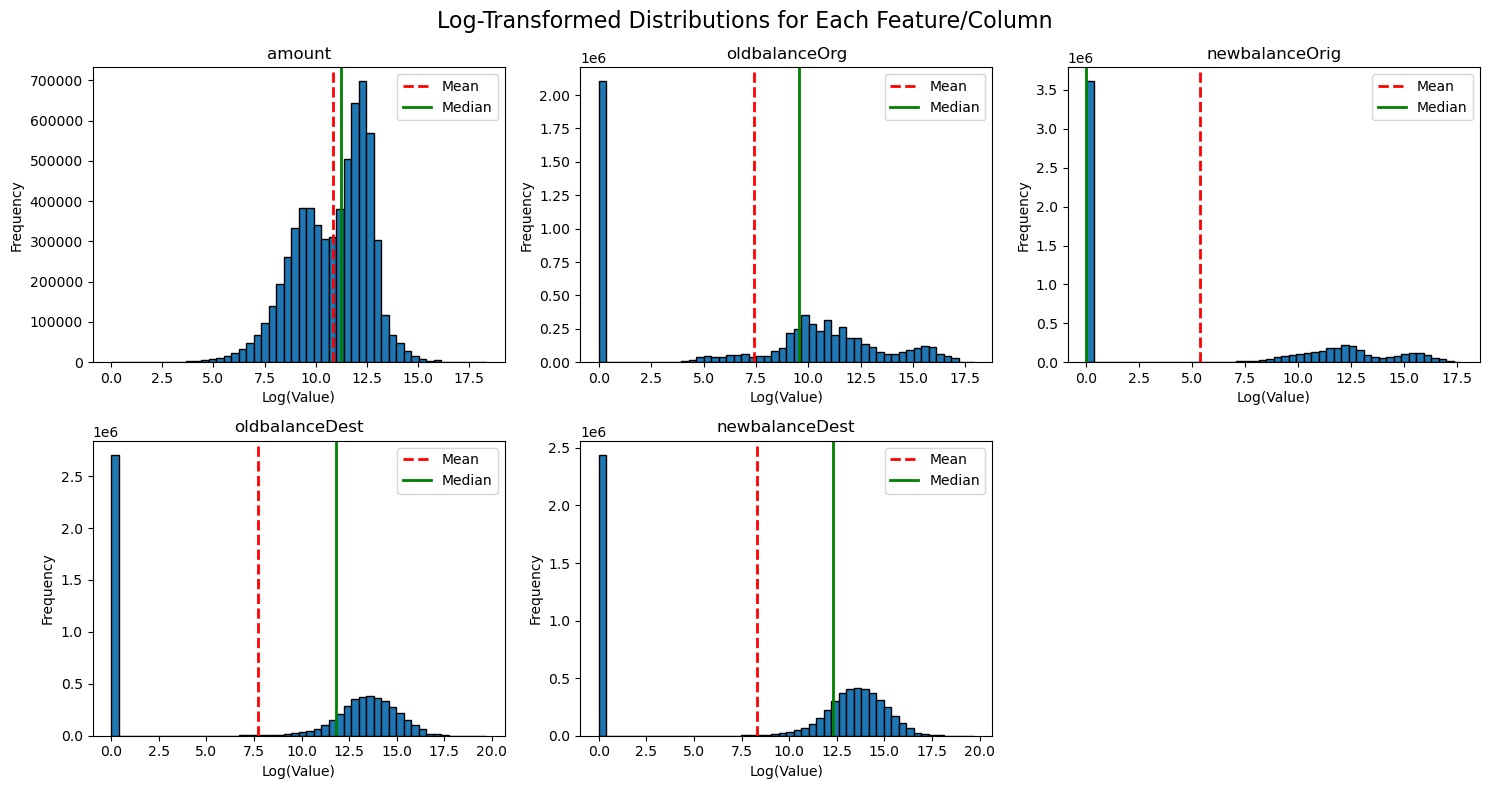

In [23]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = np.log1p(df[col])
    
    # Histogram
    axes[i].hist(data, bins=50, edgecolor='black')
    
    # Mean & Median
    mean_val = data.mean()
    median_val = data.median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label='Median')
    
    # Labels
    axes[i].set_title(col)
    axes[i].set_xlabel('Log(Value)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Remove empty subplot
fig.delaxes(axes[5])

fig.suptitle("Log-Transformed Distributions for Each Feature/Column", fontsize=16)

plt.tight_layout()
plt.show()

<u>Insights:</u> The transaction amount is highly skewed, with most values being small and a few very large outliers. Applying a log transformation helps better visualize the distribution and reveals the underlying pattern of the data.
- The `amount` column is the most balanced, with transactions spread around a clear middle range.
- The balance columns (`oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) show a large spike at zero, meaning many accounts have little to no balance.
- For the balance features, most of the actual values (non-zero) are spread out on the right side, showing a wide range of account balances.
- The mean is consistently lower than the median in the balance columns, which shows that the large number of zero values is pulling the average down.
- Compared to `amount`, the balance columns are more uneven and contain more extreme cases (especially many zero values).

#### Outliers?

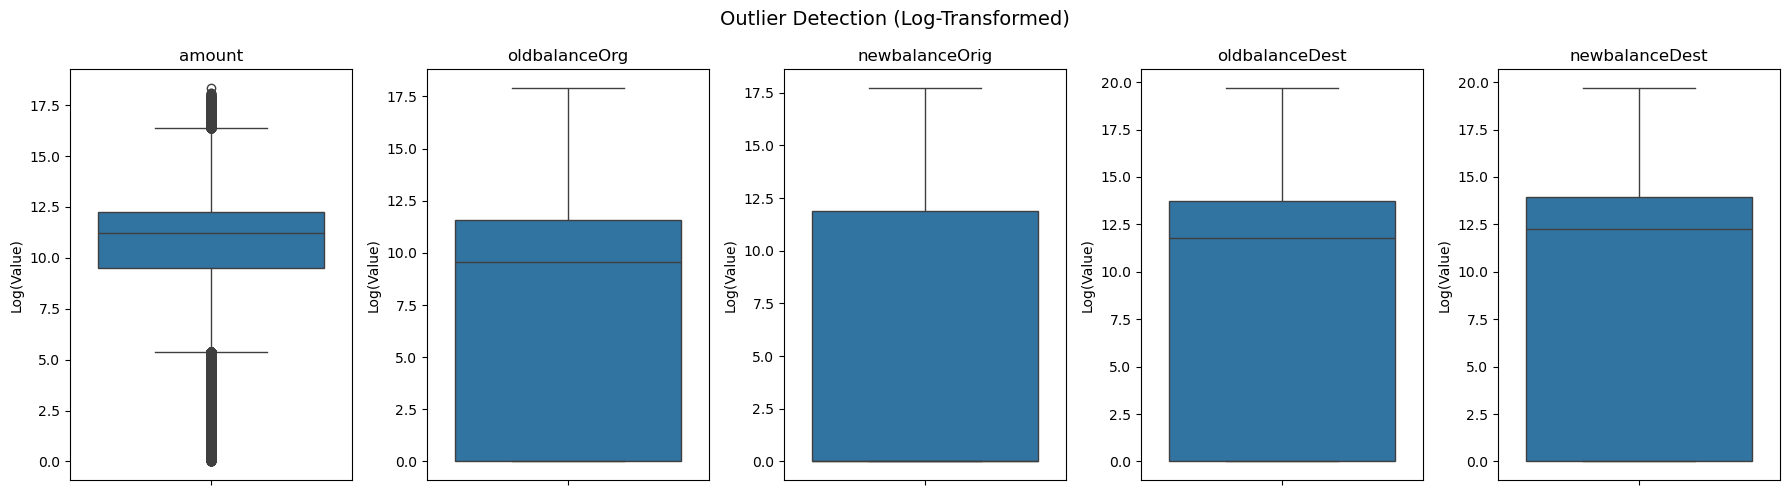

In [33]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(cols):
    data = np.log1p(df[col])
    
    sns.boxplot(y=data, ax=axes[i])
    
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Log(Value)')

plt.suptitle("Outlier Detection (Log-Transformed)", fontsize=14)

plt.tight_layout()
plt.show()

<u>Insights:</u>
- amount still has outliers, some transactions are unusually large/small (possible fraud signals)
- Sender balances (oldbalanceOrg, newbalanceOrig) jump a lot, some accounts get drained to near zero
- Receiver balances are also spread out → money flow is uneven, possibly funneled to certain accounts
- Log transform helped normalize the data, but extreme values still exist and are important to keep

#### Other Features/Columns:
- step
- type
- isFraud
- isFlaggedFraud

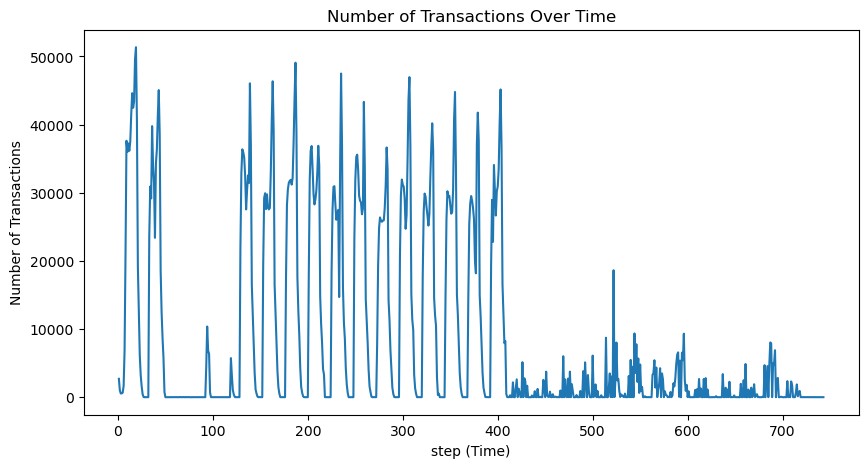

In [27]:
df.groupby('step').size().plot(figsize=(10,5))

plt.title("Number of Transactions Over Time")
plt.xlabel("step (Time)")
plt.ylabel("Number of Transactions")

plt.show()

<u>Insights:</u>

- I grouped the data by `step` to see how transaction activity changes over time.
- The number of transactions goes up and down a lot over time — it’s not steady.
- There are clear spikes where a lot of transactions happen, followed by drops where almost nothing happens.
- This is important for fraud detection because fraud may not happen randomly, it could be more likely during certain time periods.
- By looking at activity over time, we can later check if fraud cases also spike during these high-activity periods or unusual drops.


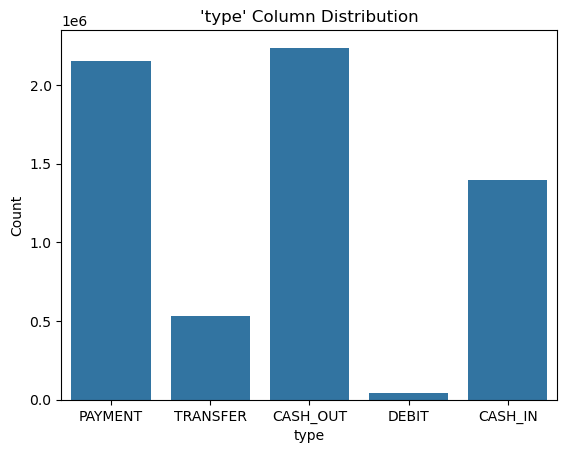

In [30]:
sns.countplot(x='type', data=df)

plt.title("'type' Column Distribution")
plt.xlabel("type")
plt.ylabel("Count")

plt.show()

<u>Insights:</u>

- CASH_OUT and PAYMENT happen the most — these are the most common transactions.
- CASH_IN also happens a lot, but not as much as CASH_OUT and PAYMENT.
- TRANSFER happens less often compared to the top ones.
- DEBIT is very rare in this dataset.
- Overall, most activity is focused on just a few transaction types.

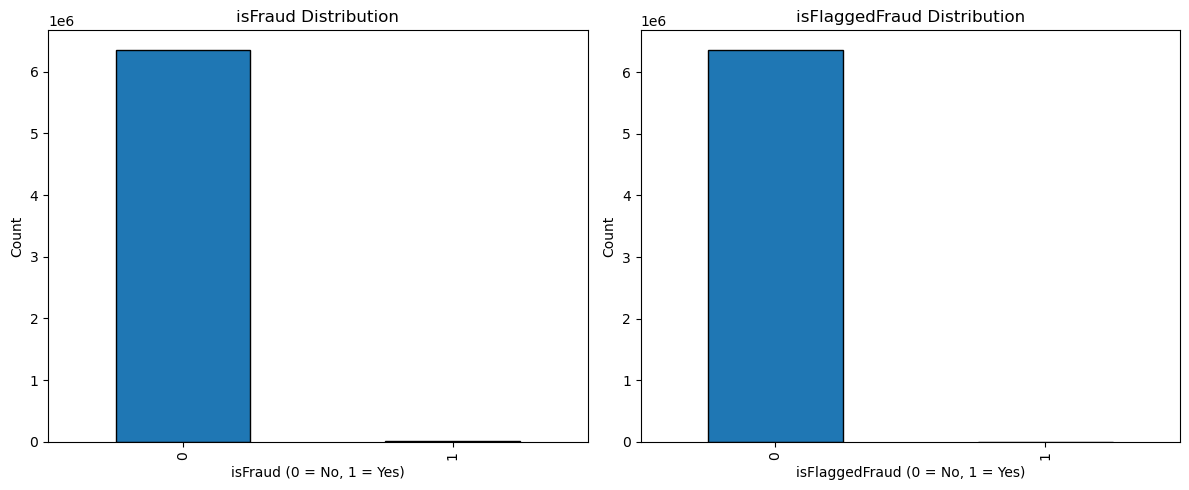

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# isFraud
df['isFraud'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title("isFraud Distribution")
axes[0].set_xlabel("isFraud (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")

# isFlaggedFraud
df['isFlaggedFraud'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title("isFlaggedFraud Distribution")
axes[1].set_xlabel("isFlaggedFraud (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

<u>Insights:</u>

- Fraud cases are very rare compared to normal transactions.
- Flagged fraud cases are also very few.
- This shows that most transactions are not fraud.
- It also suggests that the system flags only a small number of transactions as fraud.